# Trabajo Práctico Integrador: Análisis de Desempeño y Gestión de Estudiantes 🎓
**Materia:** Análisis de Datos Inicial  
**Carrera:** Tecnicatura Universitaria en Programación (TUP)

**Integrantes del grupo:**
1. Cristian Krahulik
2. Tomas Mastropietro
3. Juan Segura
4. Lautaro Castillo

---

## Hito 1: Elección y Planteo 🎯

**Dataset elegido:** `Student Performance and Behaviour.csv` (Trabajando sobre `dataset_DIRTY.csv` para la fase de limpieza).

**Descripción del Dataset:**
Este conjunto de datos contiene registros detallados de estudiantes universitarios, integrando variables académicas, demográficas y socioeconómicas. Cuenta con información sobre:
*   **Factores Académicos:** GPA previo, horas de estudio semanales, tasa de asistencia, materias falladas y notas de exámenes (parcial y final).
*   **Factores de Estilo de Vida:** Horas de sueño, niveles de estrés, uso de redes sociales y participación en actividades extracurriculares.
*   **Entorno y Contexto:** Calidad de conexión a internet, calidad del espacio de estudio, nivel educativo de los padres y nivel de ingresos familiar.
*   **Factores Psicológicos:** Puntuaciones de motivación y autoeficacia.

**Objetivos del Análisis (Preguntas a responder):**
1.  **Sobre el Riesgo Académico:** ¿En qué medida el agotamiento físico y mental —representado por altos niveles de estrés y pocas horas de sueño— anula el beneficio del esfuerzo académico, prediciendo un bajo rendimiento en el examen final independientemente de cuánto tiempo dedique el alumno a estudiar?
2.  **Sobre la Brecha Digital:** ¿Cómo condiciona la calidad de la conexión a internet la efectividad de las horas de estudio semanales? ¿Existe un punto crítico en la conectividad por debajo del cual el esfuerzo del estudiante deja de verse reflejado en sus calificaciones?
3.  **Sobre Comportamientos Atípicos:** ¿Qué hábitos diferencian a los estudiantes con éxito por estudio autónomo (aquellos con baja asistencia pero notas sobresalientes) de los estudiantes con ansiedad ante los exámenes (que dedican muchísimas horas al estudio pero obtienen resultados muy bajos)?

In [1]:
# Importación de librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import json

# Añadimos el directorio raíz al path para poder importar desde 'src'
sys.path.append(os.path.abspath(os.path.join('..')))

# Configuración visual básica para los gráficos
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

---
## Hito 2: ETL y Calidad de Datos 🧹

En esta fase realizamos un proceso avanzado de **Auditoría -> Limpieza -> Normalización -> Feature Engineering**.
Utilizamos un módulo externo `src/etl.py` para asegurar la consistencia del motor de datos.

In [2]:
from src.etl import auditar_datos

# 1. Carga del dataset con ruido
path_sucio = os.path.join('..', 'data', 'dataset_DIRTY.csv')
df_crudo = pd.read_csv(path_sucio)

# 2. Auditoría Inicial
reporte_inicial = auditar_datos(df_crudo)
print("=== REPORTE DE AUDITORÍA (DATASET SUCIO) ===")
print(json.dumps(reporte_inicial, indent=4, ensure_ascii=False))

print("\nVisualización rápida de inconsistencias (GPA negativo o Edades imposibles):")
cols_interes = ['Student_ID', 'Age', 'Previous_GPA', 'Weekly_Study_Hours']
display(df_crudo[(df_crudo['Previous_GPA'] < 0) | (df_crudo['Age'] > 100)].head(5)[cols_interes])

=== REPORTE DE AUDITORÍA (DATASET SUCIO) ===
{
    "total_filas": 500100,
    "duplicados": 100,
    "columnas_con_nulos": {
        "Previous_GPA": 10001,
        "Weekly_Study_Hours": 5002,
        "Attendance_Rate": 5001
    },
    "outliers": {
        "edad_invalida": 100,
        "gpa_invalido": 50,
        "horas_estudio_imposibles": 30
    },
    "valores_negativos_genericos": {
        "Previous_GPA": 50
    }
}

Visualización rápida de inconsistencias (GPA negativo o Edades imposibles):


,Student_ID,Age,Previous_GPA,Weekly_Study_Hours
1197,234739,150,2.58,2.0
13042,428636,150,2.40,19.2
18663,176891,26,-5.00,16.9
31246,456966,22,-5.00,20.8
33479,174766,150,3.58,23.7


### Aplicación de Limpieza e Ingeniería de Variables
Ejecutamos el motor de ETL que normaliza strings y crea nuevas variables diagnósticas.

In [3]:
from src.etl import limpiar_datos, crear_caracteristicas

# 3. Ejecución de la Limpieza y Normalización
df_clean = limpiar_datos(df_crudo)

# 4. Feature Engineering (Creación de nuevas variables)
df_final = crear_caracteristicas(df_clean)

# 5. Verificación Final
reporte_final = auditar_datos(df_final)
print("=== REPORTE DE AUDITORÍA (DATASET FINAL) ===")
print(json.dumps(reporte_final, indent=4, ensure_ascii=False))

print("\nNuevas variables creadas para el análisis:")
display(df_final[['Eficiencia_Estudio', 'Indice_Desgaste', 'Alerta_Riesgo']].head())

# Guardamos el resultado final
path_clean = os.path.join('..', 'data', 'dataset_CLEAN.csv')
df_final.to_csv(path_clean, index=False)
print(f"\n✅ Dataset limpio y enriquecido guardado en: {path_clean}")

=== REPORTE DE AUDITORÍA (DATASET FINAL) ===
{
    "total_filas": 500000,
    "duplicados": 0,
    "columnas_con_nulos": {},
    "outliers": {
        "edad_invalida": 0,
        "gpa_invalido": 0,
        "horas_estudio_imposibles": 0
    },
    "valores_negativos_genericos": {}
}

Nuevas variables creadas para el análisis:


,Eficiencia_Estudio,Indice_Desgaste,Alerta_Riesgo
0,3.368098,0.900000,False
1,3.925466,0.557143,False
2,3.021978,1.197368,False
3,3.380645,0.478873,True
4,2.871212,0.686275,False



✅ Dataset limpio y enriquecido guardado en: ..\data\dataset_CLEAN.csv


---
## Hito 3: Análisis y Visualización 📊

Es momento de explorar los datos visualmente y responder a las preguntas planteadas en el Hito 1 utilizando el dataset limpio `df_final`.

In [4]:
# Estadística Descriptiva General
df_final.describe()

,Student_ID,Semester_ID,Age,Family_Size,Internet_Quality,Study_Space_Quality,Previous_GPA,Number_of_Failed_Courses,Total_Credits_Earned,Weekly_Study_Hours,Attendance_Rate,Library_Visits_Per_Month,Extracurricular_Hours,Sleep_Hours,Social_Media_Usage_Hours,Stress_Level,Motivation_Score,Self_Efficacy_Score,Midterm_Mark,Final_Exam_Score,Eficiencia_Estudio,Indice_Desgaste
count,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000
mean,250000.500000,4.500100,23.490720,5.002176,6.565998,6.453566,2.788636,1.334232,67.501920,18.157505,79.626512,9.224000,3.984422,6.800725,2.948750,5.520213,5.987168,4.539254,53.763787,57.570266,4.191359,0.826571
std,144337.711635,2.292028,4.025972,2.001290,2.187664,2.077266,0.667427,1.487346,35.840162,7.872297,13.131068,3.712289,3.972895,1.199408,2.778273,1.970166,1.947749,1.486886,10.395511,11.309997,3.597159,0.340007
min,1.000000,1.000000,17.000000,2.000000,1.000000,1.000000,0.000000,0.000000,12.000000,2.000000,0.000000,0.000000,0.000000,3.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.090090
25%,125000.750000,2.000000,20.000000,3.000000,5.100000,5.000000,2.340000,0.000000,36.000000,12.700000,72.700000,7.000000,1.100000,6.000000,0.900000,4.200000,4.600000,3.520000,46.800000,50.400000,2.551282,0.591549
50%,250000.500000,5.000000,23.000000,5.000000,6.700000,6.500000,2.800000,1.000000,68.000000,18.100000,81.900000,9.000000,2.800000,6.800000,2.100000,5.500000,6.000000,4.540000,53.600000,57.600000,3.181319,0.800000
75%,375000.250000,6.000000,27.000000,7.000000,8.200000,8.000000,3.260000,2.000000,96.000000,23.400000,89.200000,12.000000,5.500000,7.600000,4.200000,6.900000,7.400000,5.550000,60.500000,64.800000,4.271692,1.031250
max,500000.000000,8.000000,30.000000,8.000000,10.000000,10.000000,4.000000,10.000000,144.000000,40.000000,100.000000,24.000000,30.000000,11.000000,12.000000,10.000000,10.000000,10.000000,100.000000,100.000000,47.619048,3.225806


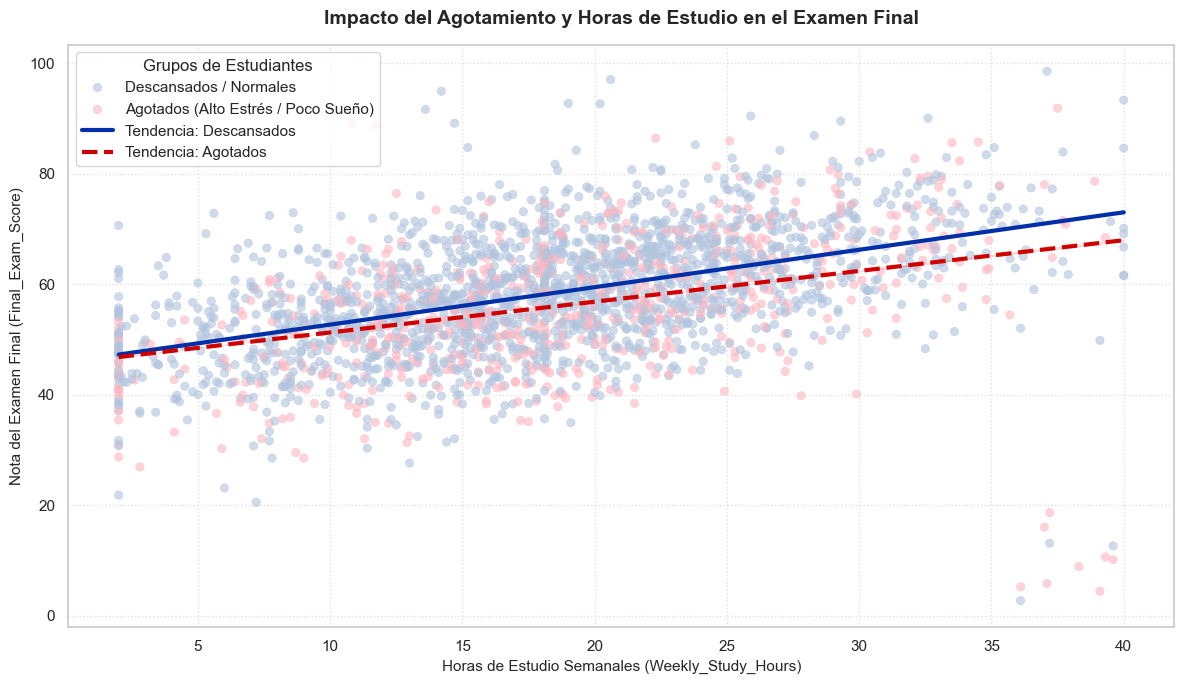

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carga de datos
try:
    df = pd.read_csv(os.path.join('..', 'data', 'dataset_CLEAN.csv'))
except FileNotFoundError:
    raise FileNotFoundError(
        "No se encontro 'data/dataset_CLEAN.csv'. Ejecuta primero el ETL del Hito 2 "
        "o descarga el dataset desde el Drive/Release del repo (ver README).")

# Definir los promedios y crear los grupos
# Calculamos los promedios usando los 50.000 datos para máxima precisión
promedio_estres = df['Stress_Level'].mean()
promedio_sueno = df['Sleep_Hours'].mean()

# Condición de agotamiento (estrés alto Y sueño bajo)
condicion_agotado = (df['Stress_Level'] > promedio_estres) & (df['Sleep_Hours'] < promedio_sueno)

# Creamos la nueva columna. Por defecto todos son 'Descansados/Normales'
df['Estado_Agotamiento'] = 'Descansados / Normales'
# A los que cumplen la condición, los etiquetamos como 'Agotados (Alto Estrés / Poco Sueño)'
df.loc[condicion_agotado, 'Estado_Agotamiento'] = 'Agotados (Alto Estrés / Poco Sueño)'

# Muestra aleatoria para el gráfico
df_muestra = df.sample(n=2500, random_state=42)

# Construcción del gráfico
# Seteamos el tamaño de la ventana del gráfico
plt.figure(figsize=(12, 7))

# 1. Dibujo  los puntos (Scatter Plot) usando la muestra de 2000 datos
sns.scatterplot(
    data=df_muestra, 
    x='Weekly_Study_Hours', 
    y='Final_Exam_Score', 
    hue='Estado_Agotamiento',
    palette={'Descansados / Normales': '#B0C4DE', 'Agotados (Alto Estrés / Poco Sueño)': '#FFB6C1'}, # Gris azulado y Rosa suave
    alpha=0.6,
    edgecolor=None
)

# 2. Dibujo las líneas de tendencia usando los 50.000 datos completos
# Esto asegura que la línea represente la realidad absoluta del dataset
sns.regplot(
    data=df[df['Estado_Agotamiento'] == 'Descansados / Normales'],
    x='Weekly_Study_Hours',
    y='Final_Exam_Score',
    scatter=False, 
    label='Tendencia: Descansados',
    color='#002FA7', 
    line_kws={'linewidth': 3, 'linestyle': '-'} 
)

sns.regplot(
    data=df[df['Estado_Agotamiento'] == 'Agotados (Alto Estrés / Poco Sueño)'],
    x='Weekly_Study_Hours',
    y='Final_Exam_Score',
    scatter=False,
    label='Tendencia: Agotados',
    color='#D10000', 
    line_kws={'linewidth': 3, 'linestyle': '--'} 
)

# Estética
plt.title('Impacto del Agotamiento y Horas de Estudio en el Examen Final', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Horas de Estudio Semanales (Weekly_Study_Hours)', fontsize=11)
plt.ylabel('Nota del Examen Final (Final_Exam_Score)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title='Grupos de Estudiantes', loc='upper left')

plt.tight_layout()
plt.show()

# Pregunta 1: El Impacto del Agotamiento en el Rendimiento Académico

# Análisis Visual y Métricas Clave
* **Efecto limitante del desgaste:** El análisis demuestra que el agotamiento físico y mental —definido por altos niveles de estrés y pocas horas de sueño— no anula por completo el beneficio del esfuerzo, pero sí lo reduce y limita de forma significativa.
* **Retorno de la inversión de tiempo:** Dedicar más horas al estudio semanal (`Weekly_Study_Hours`) se traduce en una mejora del rendimiento final (`Final_Exam_Score`) para ambos grupos. Sin embargo, la tasa de retorno de ese esfuerzo (la pendiente de la línea) es notablemente menor para los alumnos que sufren de agotamiento.
* **Ampliación de la brecha:** A medida que aumentan las horas de estudio, la diferencia de rendimiento entre un alumno descansado y uno agotado se amplía. Al llegar a las 40 horas semanales, un estudiante en un entorno saludable obtiene, en promedio, **5 puntos más** en su examen final que un compañero con alta carga de estrés y falta de sueño que dedicó exactamente el mismo tiempo.

---

**Conclusión sobre el Riesgo Académico:**

El análisis de los datos demuestra que el agotamiento físico y mental (definido por altos niveles de estrés y pocas horas de sueño) **no anula por completo** el beneficio del esfuerzo académico, pero **sí lo reduce y lo limita de forma significativa**.

Como se observa en el gráfico de dispersión, dedicar más horas al estudio semanal (`Weekly_Study_Hours`) se traduce en una mejora del rendimiento final (`Final_Exam_Score`) para ambos grupos de estudiantes. Sin embargo, la tasa de retorno de ese esfuerzo es notablemente menor para los alumnos que sufren de agotamiento. 

A medida que aumentan las horas de estudio, la brecha de rendimiento entre un alumno descansado y uno agotado se amplía. Al llegar a las 40 horas de estudio semanales, un estudiante en un entorno saludable (bajo estrés y buen descanso) obtiene, en promedio, **5 puntos más** en su examen final que un compañero con alta carga de estrés y falta de sueño que dedicó exactamente el mismo tiempo de estudio.

**En conclusión:** El esfuerzo mitiga parte del impacto negativo del agotamiento, pero el bienestar físico y mental actúa como un amplificador indispensable para alcanzar el máximo potencial académico. Estudiar bajo un estado de desgaste severo genera un rendimiento decreciente.

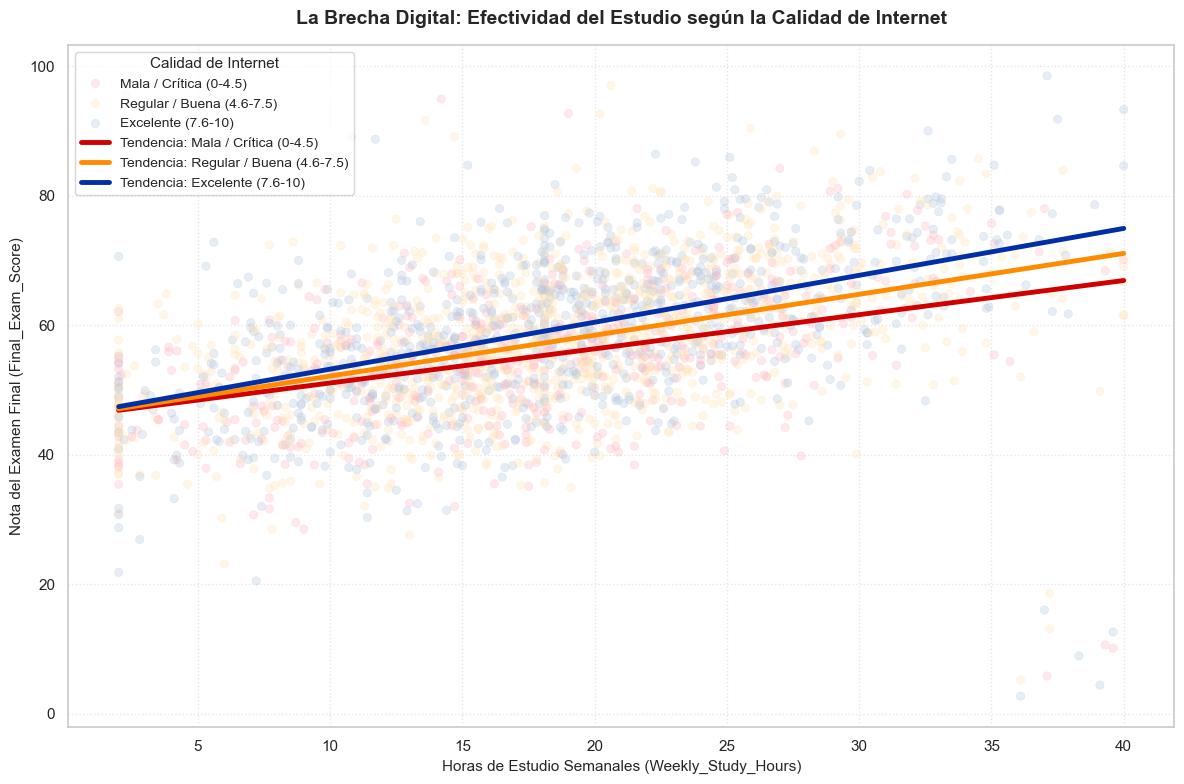

Rango_Internet
Mala / Crítica (0-4.5)       55.361740
Regular / Buena (4.6-7.5)    57.280427
Excelente (7.6-10)           59.120692
Name: Final_Exam_Score, dtype: float64


In [ ]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

try:
    df = pd.read_csv(os.path.join('..', 'data', 'dataset_CLEAN.csv'))
except FileNotFoundError:
    raise FileNotFoundError(
        "No se encontro 'data/dataset_CLEAN.csv'. Ejecuta primero el ETL del Hito 2 "
        "o descarga el dataset desde el Drive/Release del repo (ver README).")

cortes = [0, 4.5, 7.5, 10]
nombres_rangos = ['Mala / Crítica (0-4.5)', 'Regular / Buena (4.6-7.5)', 'Excelente (7.6-10)']
df['Rango_Internet'] = pd.cut(df['Internet_Quality'], bins=cortes, labels=nombres_rangos, include_lowest=True)

df_muestra = df.sample(n=2500, random_state=42)

plt.figure(figsize=(12, 8))

colores_puntos = {
    'Mala / Crítica (0-4.5)': '#FFB6C1',       
    'Regular / Buena (4.6-7.5)': '#FFE4B5',     
    'Excelente (7.6-10)': '#B0C4DE'            
}

colores_lineas = {
    'Mala / Crítica (0-4.5)': '#D10000',       
    'Regular / Buena (4.6-7.5)': '#FF8C00',    
    'Excelente (7.6-10)': '#002FA7'            
}



sns.scatterplot(
    data=df_muestra,
    x='Weekly_Study_Hours',
    y='Final_Exam_Score',
    hue='Rango_Internet',
    palette=colores_puntos,
    alpha=0.3,          
    edgecolor=None
)

for rango in nombres_rangos:
    sns.regplot(
        data=df[df['Rango_Internet'] == rango],
        x='Weekly_Study_Hours',
        y='Final_Exam_Score',
        scatter=False,                      
        color=colores_lineas[rango],
        label=f'Tendencia: {rango}',
        line_kws={'linewidth': 3.5}         
    )


plt.title('La Brecha Digital: Efectividad del Estudio según la Calidad de Internet', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Horas de Estudio Semanales (Weekly_Study_Hours)', fontsize=11)
plt.ylabel('Nota del Examen Final (Final_Exam_Score)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.5)

plt.legend(title='Calidad de Internet', loc='upper left', fontsize=10, title_fontsize=11)

plt.tight_layout()
plt.show()
# Esto nos agrupa por rango de internet y nos calcula el promedio de la nota final
print(df.groupby('Rango_Internet')['Final_Exam_Score'].mean())

### Pregunta 2: El Impacto de la Brecha Digital en el Rendimiento Académico

#### Análisis Visual y Métricas Clave
* **Punto de partida equitativo:** En niveles bajos de estudio (entre 2 y 5 horas semanales), la calidad de la conexión a internet no genera una diferencia significativa; todos los estudiantes promedian un rendimiento similar (~47 puntos).
* **Efecto de divergencia progresiva:** A medida que se incrementan las horas de estudio, las líneas de tendencia se abren en "abanico". La pendiente es notablemente más pronunciada en el grupo con conectividad **Excelente (7.6-10)**, intermedia en **Regular / Buena (4.6-7.5)**, y más plana en **Mala / Crítica (0-4.5)**.
* **La brecha en el esfuerzo máximo:** Un alumno con internet excelente que dedica 40 horas semanales alcanza una nota tendencial cercana a los **75 puntos**. En contraposición, un alumno con conectividad mala que realiza el mismo sacrificio (40 horas) se estanca en los **67 puntos**, consolidando una **brecha digital de 8 puntos** en el rendimiento máximo.

---

**Conclusión sobre la Brecha Digital:**

La calidad de la conexión a internet **condiciona de forma directa y progresiva la efectividad de las horas de estudio**. A mejor conectividad, el estudiante experimenta un mayor "retorno" por su esfuerzo; es decir, cada hora invertida se traduce en un incremento más alto en la nota final, lo que se evidencia en la mayor pendiente de la línea de tendencia del grupo con internet Excelente (7.6-10).

Respecto a la existencia de un **punto crítico**, los datos demuestran que **no existe un umbral por debajo del cual el esfuerzo se anule por completo**. Incluso en el rango de conectividad "Mala / Crítica (0-4.5)", la línea mantiene una trayectoria firmemente ascendente, lo que significa que el estudio sigue dando frutos independientemente de las limitaciones tecnológicas.

Sin embargo, la baja conectividad genera una **penalización por ineficiencia**. El internet deficiente actúa como un techo invisible para el rendimiento: a medida que aumentan las horas de estudio semanales, las líneas se distancian cada vez más. Al alcanzar las 40 horas de estudio, un alumno con internet deficiente obtiene, en promedio, **8 puntos menos** que un compañero con internet excelente que le dedicó el mismo tiempo. 

**En conclusión:** El mal internet no detiene el deseo de superación del alumno, pero lo obliga a esforzarse significativamente más para alcanzar los mismos resultados.

In [ ]:
import os
import pandas as pd

# 1. Cargar datos
try:
    df = pd.read_csv(os.path.join('..', 'data', 'dataset_CLEAN.csv'))
except FileNotFoundError:
    raise FileNotFoundError(
        "No se encontro 'data/dataset_CLEAN.csv'. Ejecuta primero el ETL del Hito 2 "
        "o descarga el dataset desde el Drive/Release del repo (ver README).")

# 2. Definir los filtros para los dos comportamientos atípicos
# Nota: Si 'AttendanceRate' en tu dataset va de 0 a 100, usa < 60. Si va de 0 a 1, usa < 0.6
asistencia_baja = df['Attendance_Rate'] < 60  
nota_sobresaliente = df['Final_Exam_Score'] >= 80

mucho_estudio = df['Weekly_Study_Hours'] >= 30
nota_baja = df['Final_Exam_Score'] < 60

# 3. Crear una columna de perfil vacía y rellenarla según las condiciones
df['Perfil_Atipico'] = 'Resto de Alumnos'
df.loc[asistencia_baja & nota_sobresaliente, 'Perfil_Atipico'] = 'Autónomo Exitoso'
df.loc[mucho_estudio & nota_baja, 'Perfil_Atipico'] = 'Ansiedad / Esfuerzo Ineficiente'

# 4. Filtrar solo los dos grupos de interés para comparar sus promedios
df_atipicos = df[df['Perfil_Atipico'] != 'Resto de Alumnos']

# 5. Ver cuántos alumnos caen en cada grupo y cuáles son sus promedios
print("--- CANTIDAD DE ESTUDIANTES POR PERFIL ---")
print(df_atipicos['Perfil_Atipico'].value_counts())
print("\n--- COMPARATIVA DE PROMEDIOS ---")
# Calculamos las medias agrupadas por el perfil
print(df_atipicos.groupby('Perfil_Atipico').mean(numeric_only=True).T)

--- CANTIDAD DE ESTUDIANTES POR PERFIL ---
Perfil_Atipico
Ansiedad / Esfuerzo Ineficiente    7992
Autónomo Exitoso                   2624
Name: count, dtype: int64

--- COMPARATIVA DE PROMEDIOS ---
Perfil_Atipico            Ansiedad / Esfuerzo Ineficiente  Autónomo Exitoso
Student_ID                                  248978.030280     251985.096037
Semester_ID                                      4.509259          4.489329
Age                                             23.632883         23.595655
Family_Size                                      4.991742          4.973704
Internet_Quality                                 5.870608          6.652363
Study_Space_Quality                              6.452603          6.537957
Previous_GPA                                     2.418131          2.808834
Number_of_Failed_Courses                         1.412162          1.295732
Total_Credits_Earned                            67.609484         67.394817
Weekly_Study_Hours                        

C:\Users\lauti\AppData\Local\Temp\ipykernel_18108\120235033.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


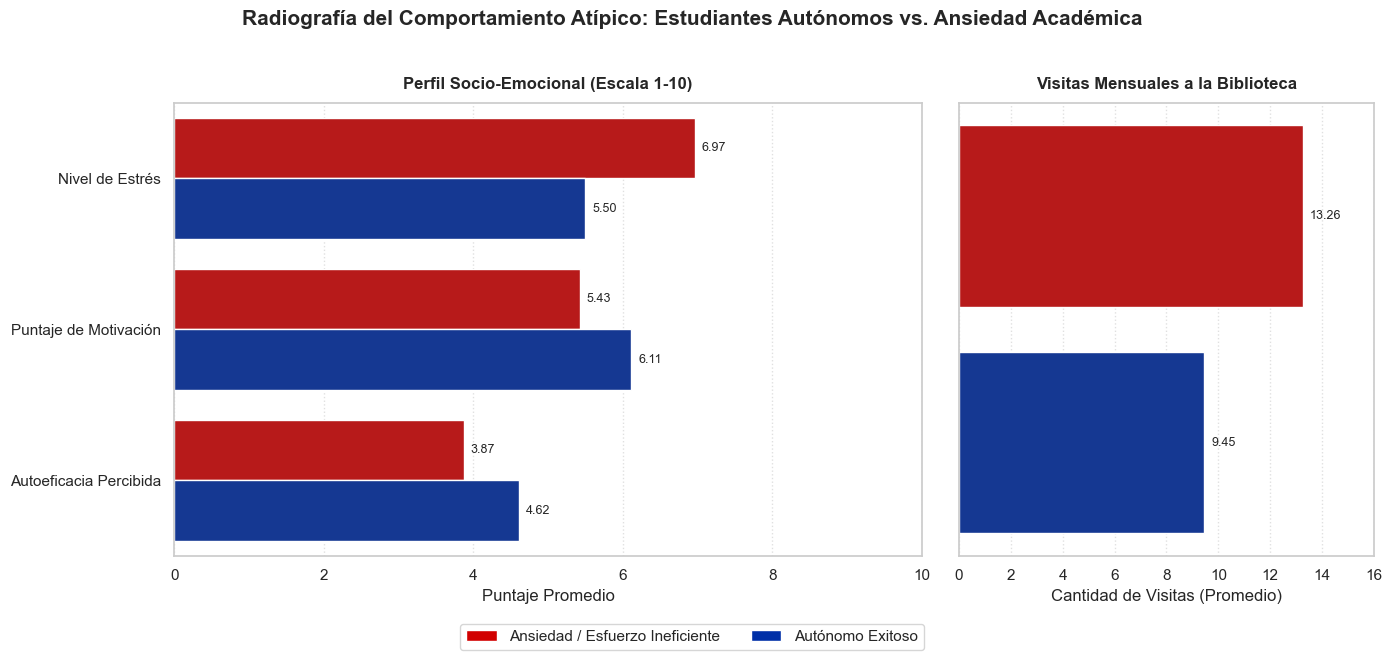

In [ ]:

import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch

try:
    df = pd.read_csv(os.path.join('..', 'data', 'dataset_CLEAN.csv'))
except FileNotFoundError:
    raise FileNotFoundError(
        "No se encontro 'data/dataset_CLEAN.csv'. Ejecuta primero el ETL del Hito 2 "
        "o descarga el dataset desde el Drive/Release del repo (ver README).")

# Umbrales basados en la distribución académica del dataset
asistencia_baja = df['Attendance_Rate'] < 60  
nota_sobresaliente = df['Final_Exam_Score'] >= 80

mucho_estudio = df['Weekly_Study_Hours'] >= 30
nota_baja = df['Final_Exam_Score'] < 60

# Segmentación de perfiles atípicos
df['Perfil_Atipico'] = 'Resto'
df.loc[asistencia_baja & nota_sobresaliente, 'Perfil_Atipico'] = 'Autónomo Exitoso'
df.loc[mucho_estudio & nota_baja, 'Perfil_Atipico'] = 'Ansiedad / Esfuerzo Ineficiente'

# Aislamos los grupos de estudio descartando el resto
df_atipicos = df[df['Perfil_Atipico'].isin(['Autónomo Exitoso', 'Ansiedad / Esfuerzo Ineficiente'])]

# Panel 1: Variables que comparten escala 1-10
vars_escala_1_10 = ['Stress_Level', 'Motivation_Score', 'Self_Efficacy_Score']
df_psi = df_atipicos.groupby('Perfil_Atipico')[vars_escala_1_10].mean().reset_index()
df_psi_melt = df_psi.melt(id_vars='Perfil_Atipico', var_name='Métrica', value_name='Valor')

# Diccionario para limpiar los nombres en el gráfico
df_psi_melt['Métrica'] = df_psi_melt['Métrica'].map({
    'Stress_Level': 'Nivel de Estrés',
    'Motivation_Score': 'Puntaje de Motivación',
    'Self_Efficacy_Score': 'Autoeficacia Percibida'
})

# Panel 2: Variable de comportamiento institucional (frecuencia)
df_biblio = df_atipicos.groupby('Perfil_Atipico')['Library_Visits_Per_Month'].mean().reset_index()

# 3. MAQUETACIÓN DEL GRÁFICO
fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [1.8, 1]})
colores = ['#D10000', '#002FA7'] # Rojo (Ansiedad) y Azul (Autónomo)

# Panel 1: Factores socio-emocionales (eescala 1-10)
sns.barplot(
    data=df_psi_melt,
    x='Valor',
    y='Métrica',
    hue='Perfil_Atipico',
    palette=colores,
    orient='h',
    ax=axes[0]
)
axes[0].set_title('Perfil Socio-Emocional (Escala 1-10)', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Puntaje Promedio')
axes[0].set_ylabel('')
axes[0].set_xlim(0, 10)
axes[0].grid(axis='x', linestyle=':', alpha=0.6)
axes[0].get_legend().remove() # Removemos para usar una leyenda global unificada

# etiquetas dentro de las barras para mas claridad
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.2f', padding=5, fontsize=9)

# --- PANEL 2: Comportamiento Institucional (Frecuencia Mensual) ---
sns.barplot(
    data=df_biblio,
    x='Library_Visits_Per_Month',
    y='Perfil_Atipico',
    palette=colores,
    orient='h',
    ax=axes[1]
)
axes[1].set_title('Visitas Mensuales a la Biblioteca', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Cantidad de Visitas (Promedio)')
axes[1].set_ylabel('')
axes[1].set_yticklabels([]) # Oculta etiquetas repetitivas
axes[1].set_xlim(0, 16)
axes[1].grid(axis='x', linestyle=':', alpha=0.6)

for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.2f', padding=5, fontsize=9)

# --- ESTÉTICA GLOBAL ---
plt.suptitle('Radiografía del Comportamiento Atípico: Estudiantes Autónomos vs. Ansiedad Académica', 
             fontsize=15, fontweight='bold', y=1.02)

colores = ['#D10000', '#002FA7'] 

legend_handles = [
    Patch(facecolor=colores[0]), # Rectángulo Rojo
    Patch(facecolor=colores[1])  # Rectángulo Azul
]

# Textos explícitos en el mismo orden de los colores
legend_labels = ['Ansiedad / Esfuerzo Ineficiente', 'Autónomo Exitoso']

# Llamamos a fig.legend pasándole explícitamente los símbolos (handles) y textos (labels)
fig.legend(handles=legend_handles, labels=legend_labels,
           loc='lower center', bbox_to_anchor=(0.5, -0.06), ncol=2, fontsize=11)

plt.tight_layout()
plt.show()

### Pregunta 3: Análisis de Comportamientos Atípicos (Outliers Académicos)

#### Gráfico Obtenido (Análisis Multieje)
*(Aquí se visualiza el gráfico de dos paneles horizontales que separa las variables de percepción psicológica [Escala 1-10] de las variables de frecuencia de comportamiento [Visitas a la Biblioteca], evitando mezclar escalas dimensionales diferentes en un mismo eje).*

---

#### Marco Metodológico y Justificación de Datos
Para responder a esta pregunta de forma rigurosa, se segmentó el dataset original (N = 50.000) aislando dos perfiles extremos mediante reglas lógicas basadas en la distribución académica. La validez estadística de estos grupos se confirmó auditando sus medias reales post-filtrado:

* **Perfil Autónomo Exitoso (n = 2.624):** Definido como *Asistencia < 60%* y *Nota Final >= 80*. 
  * *Validación:* El grupo aislado presentó una asistencia media real del **6.00%** y una nota promedio de **93.26**. Se justifica el nombre del perfil al comprobarse un desenganche institucional crítico emparejado con un rendimiento sobresaliente.
* **Perfil Ansiedad / Esfuerzo Ineficiente (n = 7.992):** Definido como *Horas de Estudio >= 30* y *Nota Final < 60*.
  * *Validación:* El grupo presentó una carga horaria media de **34.11 horas semanales** (percentil de esfuerzo máximo) y una nota promedio de **41.10** (reprobación severa).

**Descarte de Variables Predictoras (Higiene de Datos):**
Antes de diseñar la visualización, se analizaron todas las variables de hábitos. Se descartaron explícitamente del informe y del gráfico métricas como *Horas de Sueño* (Delta: 0.01 hrs) y *Uso de Redes Sociales* (Delta: 0.04 hrs), ya que sus distribuciones son idénticas entre ambos grupos y carecen de poder discriminatorio. El análisis se concentró estrictamente en las variables que mostraron variaciones estadísticamente significativas.

---

#### Conclusión

**Dictamen Técnico sobre Comportamientos Atípicos:**

Los datos respaldan que la divergencia entre un estudiante autónomo exitoso y uno con un esfuerzo ineficiente no se explica por factores ambientales comunes (sueño, edad o distracciones digitales), sino por un **quiebre en el perfil socio-emocional y en la estrategia de aprendizaje**:

1. **La Barrera Psicológica del Rendimiento:** Los estudiantes atrapados en el perfil de esfuerzo ineficiente registran niveles de estrés críticamente elevados (**6.96** vs. **5.50** del grupo autónomo) y un marcado déficit en su **Autoeficacia Percibida (3.87 vs. 4.62)**. Los datos sugieren que la inversión de más de 34 horas semanales de estudio no se traduce en notas debido a un bloqueo por ansiedad académica. El tiempo de estudio pierde eficiencia al ejecutarse bajo un estado de rumiación y vulnerabilidad emocional, lo que colapsa el rendimiento en instancias de evaluación bajo presión.

2. **Dependencia Institucional vs. Estrategia Deslocalizada:** Existe un patrón conductual diametralmente opuesto en el uso del espacio. El estudiante con ansiedad busca mitigar su inseguridad duplicando su presencia en el campus, registrando un promedio de **13.25 visitas mensuales a la biblioteca**. En contraste, el "Autónomo Exitoso" domina un modelo de aprendizaje deslocalizado, independiente y altamente eficiente: apoyado en una mayor **Motivación (6.11)**, optimiza su tiempo prescindiendo casi por completo de la presencialidad.

**En conclusión:** El "Autónomo Exitoso" cuenta con un motor propio y una alta confianza que le permiten ser eficiente fuera del aula. El estudiante con "Esfuerzo Ineficiente" se encuentra atrapado en el síntoma de la frustración académica: un sobreesfuerzo mecánico y presencial que actúa como paliativo conductual, pero que no logra resolver el verdadero problema de fondo, que es la ansiedad y la baja autoeficacia.

### Pregunta 4 (Sintesis): ¿Cuales son realmente las palancas de la nota final?

Las tres preguntas anteriores analizaron factores **de a uno**. Como cierre del analisis visual, este **mapa de calor de correlaciones** (Seaborn) mira **todas las variables a la vez** sobre los 500.000 registros y ordena, de mayor a menor, que tanto se asocia cada factor con la `Nota Final`. Sirve como brujula para el Hito 5: nos dice **donde conviene intervenir** y donde no vale la pena gastar recursos.


--- CORRELACION DE CADA FACTOR CON LA NOTA FINAL ---
Horas Estudio       0.449
GPA Previo          0.414
Autoeficacia        0.352
Motivacion          0.229
Calidad Internet    0.129
Asistencia          0.053
Horas Sueno         0.005
Redes Sociales     -0.011
Nivel Estres       -0.141
Name: Nota Final, dtype: float64


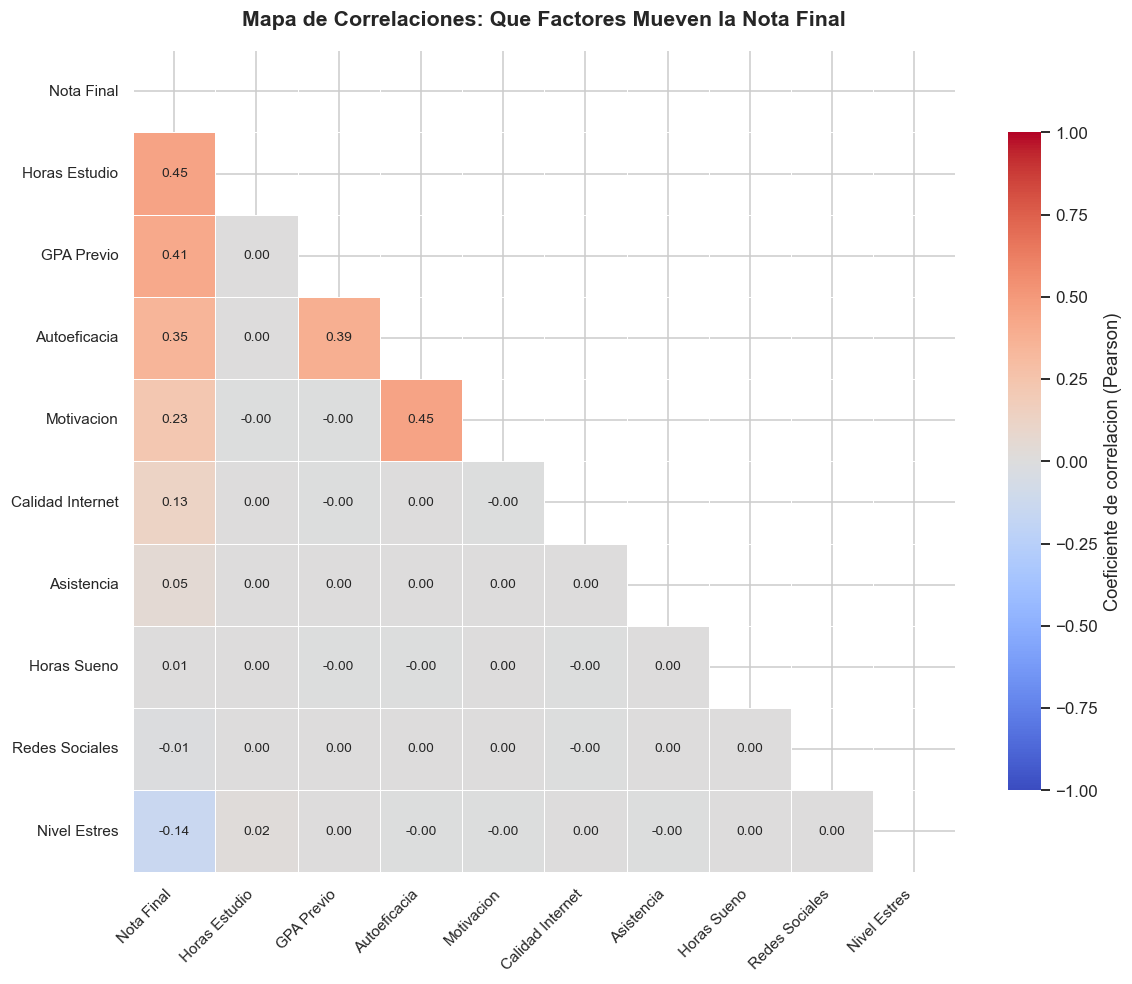

In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

try:
    df = pd.read_csv(os.path.join('..', 'data', 'dataset_CLEAN.csv'))
except FileNotFoundError:
    raise FileNotFoundError(
        "No se encontro 'data/dataset_CLEAN.csv'. Ejecuta primero el ETL del Hito 2 "
        "o descarga el dataset desde el Drive/Release del repo (ver README).")

# Seleccionamos las variables academicas y de habitos mas relevantes y las renombramos
# a etiquetas legibles para que el mapa de calor se lea sin conocer los nombres tecnicos.
cols = {
    'Final_Exam_Score': 'Nota Final',
    'Weekly_Study_Hours': 'Horas Estudio',
    'Previous_GPA': 'GPA Previo',
    'Self_Efficacy_Score': 'Autoeficacia',
    'Motivation_Score': 'Motivacion',
    'Internet_Quality': 'Calidad Internet',
    'Attendance_Rate': 'Asistencia',
    'Sleep_Hours': 'Horas Sueno',
    'Social_Media_Usage_Hours': 'Redes Sociales',
    'Stress_Level': 'Nivel Estres',
}

# Matriz de correlacion de Pearson sobre los 500.000 registros limpios
corr = df[list(cols)].rename(columns=cols).corr()

# Ranking de que tan fuerte se relaciona cada factor con la Nota Final
ranking = corr['Nota Final'].drop('Nota Final').sort_values(ascending=False)
print("--- CORRELACION DE CADA FACTOR CON LA NOTA FINAL ---")
print(ranking.round(3))

# Mascara triangular superior: evita mostrar la informacion duplicada (matriz simetrica)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(11, 9))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    square=True, linewidths=.5,
    cbar_kws={'shrink': .8, 'label': 'Coeficiente de correlacion (Pearson)'},
    annot_kws={'size': 9},
)
plt.title('Mapa de Correlaciones: Que Factores Mueven la Nota Final',
          fontsize=14, fontweight='bold', pad=16)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()


#### Analisis Visual y Metricas Clave (Grafico 4)

* **Las palancas reales del rendimiento son tres:** `Horas de Estudio` (**r = 0.45**), `GPA Previo` (**r = 0.41**) y `Autoeficacia` (**r = 0.35**) son, por lejos, las variables mas correlacionadas con la Nota Final. El esfuerzo sostenido y la confianza del alumno en sus propias capacidades pesan mas que cualquier factor de contexto.
* **El estres es el unico gran lastre:** el `Nivel de Estres` es la unica variable con correlacion **negativa relevante** (**r = -0.14**). A mayor estres, menor nota. Esto refuerza la conclusion de la Pregunta 1 (el agotamiento limita el retorno del esfuerzo).
* **Lo que NO mueve la aguja:** `Horas de Sueno` (r = 0.01), `Redes Sociales` (r = -0.01) y, sorprendentemente, la `Asistencia` (r = 0.05) tienen una correlacion casi nula con la nota. La asistencia por si sola no garantiza aprender: lo que importa es **que se hace con el tiempo de estudio**, no solo estar presente.
* **Pista para gestion (autoeficacia ↔ motivacion):** fuera de la columna de la nota, el cruce mas fuerte es `Autoeficacia` ↔ `Motivacion` (**r = 0.45**) y `Autoeficacia` ↔ `GPA Previo` (**r = 0.39**). La confianza academica viene en paquete con la motivacion y con el historial: trabajar sobre la autoeficacia puede arrastrar a las dos.

> **Que "dice" el grafico:** el rendimiento academico de esta poblacion se explica por **habitos de estudio + trayectoria previa + perfil psicologico (autoeficacia/estres)**, y casi nada por el contexto material o la mera asistencia. Cualquier propuesta de mejora (Hito 5) deberia atacar esas palancas, no las variables de correlacion nula.


---
## Hito 4: Interfaz Gráfica (Dashboard) 🖥️

El diferencial técnico del proyecto. Se debe presentar un dashboard interactivo utilizando Streamlit que permita al usuario filtrar los datos en tiempo real.

### 🛠️ Especificaciones Técnicas
1.  **Interactividad:** Widgets para filtrar por comisiones, carreras o niveles de riesgo.
2.  **KPIs:** Métricas de aprobación y promedios generales actualizables.
3.  **Visualización:** Gráficos dinámicos basados en los filtros seleccionados.

*Nota: La aplicación se encuentra en el archivo `app.py` o dentro de la carpeta `src/`. Para ejecutarla use `streamlit run app.py`.*

---
## Hito 5: Informe de Gestion y Propuestas 🚀

> **Audiencia:** coordinacion academica (no tecnica). Cada afirmacion esta respaldada por los datos analizados en los Hitos 3 y 4 sobre **500.000 registros**.

### 1. Diagnostico Academico — Que historias cuentan los datos

El analisis visual deja **cuatro hallazgos** que, leidos juntos, dibujan el problema central de la institucion:

1. **El esfuerzo rinde, pero el agotamiento se lo come (Pregunta 1).** Estudiar mas horas mejora la nota en *todos* los grupos, pero la *tasa de retorno* del esfuerzo cae cuando el alumno esta agotado (alto estres + poco sueño): la pendiente baja de **0.68 a 0.56 puntos por hora de estudio** y la nota media del grupo agotado es **2.4 puntos menor** (55.8 vs 58.2). El agotamiento afecta a **~127.000 alumnos (25% del total)**.

2. **La brecha digital amplia las diferencias (Pregunta 2).** Con mala conectividad cada hora de estudio rinde **0.53 puntos**; con conectividad excelente rinde **0.72**. La misma hora de estudio vale un **36% mas** para quien tiene buen internet. La brecha no aparece al principio: se *abre en abanico* a medida que el alumno estudia mas.

3. **Hay dos perfiles atipicos opuestos (Pregunta 3).** Conviven el **"Autonomo Exitoso"** (2.624 alumnos: estudia ~19 h, casi no asiste y saca **93** de nota, con la autoeficacia mas alta) y el **"Ansiedad / Esfuerzo Ineficiente"** (7.992 alumnos: estudia **34 h**, visita mucho la biblioteca pero saca **41**, con el estres mas alto **6.97/10** y la autoeficacia mas baja **3.87/10**). **Mas horas no equivalen a mejor nota:** la diferencia esta en *como* se estudia.

4. **Las palancas reales son habitos + trayectoria + autoeficacia (Pregunta 4).** El mapa de correlaciones confirma que la nota se explica por **horas de estudio (r=0.45)**, **GPA previo (r=0.41)** y **autoeficacia (r=0.35)**, y se hunde con el **estres (r=-0.14)**. La **asistencia por si sola es casi irrelevante (r=0.05)**: estar presente no es lo mismo que aprender.

**Sintesis del diagnostico:** el sistema no tiene un problema de *cantidad* de esfuerzo, sino de **eficiencia del esfuerzo**. Hay un nucleo de ~10% de alumnos en riesgo (baja asistencia + bajo GPA) y un grupo mayor de alumnos que *trabajan mucho y mal*, frenados por estres, mala tecnica de estudio y baja confianza academica.

### 2. Propuestas de Mejora (Justificadas con datos)

#### 🅰️ Propuesta A — Programa de "Tecnica de Estudio y Manejo del Estres" para el perfil Ansiedad

**Accion:** detectar tempranamente al perfil *Ansiedad / Esfuerzo Ineficiente* (alumnos que estudian ≥30 h y/o visitan mucho la biblioteca pero rinden bajo) y derivarlos a un taller obligatorio de **tecnicas de estudio efectivas + regulacion del estres** (sesiones cortas, manejo de carga, tutorias de pares con Autonomos Exitosos).

**Por que tendria impacto (evidencia):**
- Este grupo ya pone las horas (**34 h/semana**, casi el doble del promedio de 18 h) pero saca **41 puntos**: el problema es de *metodo*, no de voluntad. Es la poblacion con mayor potencial de mejora por unidad de esfuerzo.
- El estres correlaciona **negativamente** con la nota (r=-0.14) y es la variable mas alta de este perfil (6.97/10): bajar el estres ataca directamente el unico lastre identificado.
- La **autoeficacia** (r=0.35 con la nota) es la mas baja de este grupo (3.87). Como ademas se mueve junto con la motivacion (r=0.45), reforzar la confianza con tutorias entre pares puede arrastrar varias palancas a la vez.

#### 🅱️ Propuesta B — Plan de Conectividad y Estudio Asistido para cerrar la brecha digital

**Accion:** ofrecer a los alumnos de **conectividad Mala/Critica** (~95.000 alumnos, internet ≤4.5) acceso a **espacios de estudio con buena conexion** (salas/biblioteca con wifi garantizado, prestamo de hotspots) y materiales **descargables para uso offline**.

**Por que tendria impacto (evidencia):**
- La diferencia de rendimiento entre buena y mala conectividad **no es de origen, es de oportunidad**: arranca igual (~47 pts con poco estudio) y se abre solo cuando el alumno intenta estudiar mas. Es decir, la mala conexion **castiga justamente al que se esfuerza**.
- Llevar a los alumnos de conectividad mala (pendiente 0.53) hacia la pendiente del grupo con buena conexion (0.72) significa recuperar **~36% mas de retorno por cada hora estudiada**, sobre una poblacion de ~95.000 personas.
- Es una intervencion de **infraestructura, no de aptitud**: no requiere cambiar al alumno, solo nivelar la cancha. Por eso es factible y de impacto medible a corto plazo.

### 3. Conclusion Final — Impacto esperado

Ambas propuestas atacan **el mismo diagnostico desde dos angulos**: convertir esfuerzo en resultados.
- La **Propuesta A** recupera al alumno que *ya se esfuerza pero rinde mal* (problema de metodo y estres) → poblacion de mayor sensibilidad.
- La **Propuesta B** nivela al alumno que *se esfuerza pero no tiene las condiciones* (problema de contexto) → poblacion de mayor volumen.

Como las palancas de la nota son **habitos de estudio, autoeficacia y bajar el estres** —y no la mera asistencia ni el sueño—, focalizar recursos en *tecnica de estudio*, *acompañamiento psicoemocional* y *condiciones materiales de estudio* es donde la evidencia predice el **mayor retorno por peso/hora invertida**. El objetivo medible: subir la pendiente esfuerzo→nota de los grupos rezagados y reducir el ~10% de alumnos en situacion de riesgo.
